# EPOCH Pilot Final Task


* 선택한 도메인 - **스포츠(축구)**
* 이유 및 동기 - **평소에 관심갖는 분야 + PILOT이라는 가벼운 마음가짐**
* 해결해보고 싶은 과제 - **선수들의 몸값은 어떤 게 원인이 될까? 실제 실력의 몇 퍼센트일까?**


# TASK 1. 데이터 출처 설명 / 데이터 불러오기


* 데이터 - https://github.com/dcaribou/transfermarkt-datasets?tab=readme-ov-file


* 데이터셋 정보 - Clean, structured and automatically updated football (soccer) dataset built from Transfermarkt data -- 68,000+ games, 30,000+ players, 1,500,000+ appearances and more, refreshed weekly.


* 해석: **Transfermarkt**(선수들 가치와 스탯을 정리해놓은 플랫폼) 데이터를 기반으로 구축된 깔끔하고 구조화된 축구(사커) 데이터셋 — 68,000개 이상의 경기, 30,000명 이상의 선수, 1,500,000건 이상의 출전 기록 등을 포함하며, 매주 업데이트됩니다.


# Table	Description	Scale


*   competitions - Leagues and tournaments (40*)
*   clubs - Club details, squad size, market value (400+)
*   players - 	Player profiles, positions, market values (30,000+)
*   games - Match results, lineups, attendance (68,000+)
*   appearances - One row per player per game played (1,500,000+)
*   player_valuations - Historical market value records (450,000+)
*   club_games - Per-club view of each game (136,000+)
*   game_events - Goals, cards, substitutions (950,000+)
*   game_lineups - Starting and bench lineups (81,000+)
*   transfers - Player transfers between clubs (--)


# 1. 수치형 변수 (Numerical Variables)
* market_value_in_eur : 현재 이적시장 가치 (예측해야 할 타겟 변수, 단위: 유로)
* highest_market_value_in_eur : 선수의 역대 최고 몸값
* height_in_cm : 선수의 키
* goals : 득점 수 (appearances 테이블에서 합산하여 생성)
* assists : 어시스트 수 (appearances 테이블에서 합산하여 생성)
* minutes_played : 총 출전 시간 (appearances 테이블에서 합산하여 생성)
* age : 나이 (생년월일인 date_of_birth를 기준으로 현재 연도에서 빼서 새롭게 만들 파생 변수)

# 2. 범주형 변수 (Categorical Variables)
* position : 대분류 포지션 (예: Attack, Defender, Midfield, Goalkeeper)
* sub_position : 세부 포지션 (예: Centre-Forward, Centre-Back 등)
* foot : 주로 쓰는 발 (예: right, left, both)
* country_of_citizenship : 국적 (예: Spain, Brazil, Korea, South 등)
* current_club_id : 현재 소속된 구단의 고유 ID
* current_club_domestic_competition_id : 소속 리그 (예: GB1-프리미어리그, ES1-라리가 등)
* player_id : 선수의 고유 식별 번호 (데이터 병합용 Key 변수이며, 모델링할 때는 제외)

# 데이터셋 확인해보기

**players, appearances, player_valuations**를 확인해볼 예정입니다

In [270]:
import pandas as pd

# players 데이터셋 불러오기
df_players_bf = pd.read_csv('/content/players.csv.gz')
df_raw = df_players_bf.copy()

In [271]:
df_players_bf.head()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
0,10,Miroslav,Klose,Miroslav Klose,2015,398,miroslav-klose,Poland,Opole,Germany,...,right,184,NaN,ASBW Sport Marketing,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miroslav-klose...,IT1,Società Sportiva Lazio S.p.A.,"1,000,000","30,000,000"
1,26,Roman,Weidenfeller,Roman Weidenfeller,2017,16,roman-weidenfeller,Germany,Diez,Germany,...,left,190,NaN,Neubauer 13 GmbH,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/roman-weidenfe...,L1,Borussia Dortmund,"750,000","8,000,000"
2,65,Dimitar,Berbatov,Dimitar Berbatov,2015,1091,dimitar-berbatov,Bulgaria,Blagoevgrad,Bulgaria,...,NaN,NaN,NaN,CSKA-AS-23 Ltd.,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/dimitar-berbat...,GR1,Panthessalonikios Athlitikos Omilos Konstantin...,"1,000,000","34,500,000"
3,77,NaN,Lúcio,Lúcio,2012,506,lucio,Brazil,Brasília,Brazil,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/lucio/profil/s...,IT1,Juventus Football Club,"200,000","24,500,000"
4,80,Tom,Starke,Tom Starke,2017,27,tom-starke,East Germany (GDR),Freital,Germany,...,right,194,NaN,IFM,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/tom-starke/pro...,L1,FC Bayern München,"100,000","3,000,000"


In [272]:
df_players_bf.tail()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
34304,1498276,Ahmed,Traore,Ahmed Traore,2025,6646,ahmed-traore,Cote d'Ivoire,Yamoussoukro,Cote d'Ivoire,...,left,174,2028-06-30 00:00:00,Tamegnon Consulting,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/ahmed-traore/p...,TR1,Fatih Karagümrük Sportif Faaliyetler San. Tic....,NaN,NaN
34305,1500143,Moussa,Kone,Moussa Kone,2025,6646,moussa-kone,Cote d'Ivoire,Daloa,Cote d'Ivoire,...,right,185,2028-06-30 00:00:00,Tamegnon Consulting,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/moussa-kone/pr...,TR1,Fatih Karagümrük Sportif Faaliyetler San. Tic....,NaN,NaN
34306,1507992,Ransford,Amoo,Ransford Amoo,2025,443,ransford-amoo,NaN,NaN,Ghana,...,NaN,NaN,2030-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/ransford-amoo/...,DK1,Vejle Boldklub,NaN,NaN
34307,1510255,Miguel,Silva,Miguel Silva,2025,979,miguel-silva,NaN,NaN,Portugal,...,NaN,NaN,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/miguel-silva/p...,PO1,Moreirense Futebol Clube,NaN,NaN
34308,1511508,Yaya,Onogo,Yaya Onogo,2025,6646,yaya-onogo,Cote d'Ivoire,Abongoua Kotobi,Cote d'Ivoire,...,right,NaN,2028-06-30 00:00:00,Tamegnon Consulting,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/yaya-onogo/pro...,TR1,Fatih Karagümrük Sportif Faaliyetler San. Tic....,NaN,NaN


# 문제점 발견

데이터 양이 너무 방대합니다.

축구를 좀 봤던 저에게 있어서도 정말 처음 보는 선수가 head와 tail에서 발견됐습니다.

그래서 그 폭을 줄여보려고 합니다

In [273]:
# last_season 컬럼이 2023 이상인 데이터만 남깁니다
df_recent = df_players_bf[df_players_bf['last_season'] >= 2023]

In [274]:
# 선수들이 뛰고 있는 리그도 '유럽 5대 빅리그' 선수만 남겨서 데이터 양을 압축합니다
# GB1: 잉글랜드 프리미어리그, ES1: 스페인 라리가, IT1: 이탈리아 세리에A,
# L1: 독일 분데스리가, FR1: 프랑스 리그앙
big_5_leagues = ['GB1', 'ES1', 'IT1', 'L1', 'FR1']
df_players = df_recent[df_recent['current_club_domestic_competition_id'].isin(big_5_leagues)]

In [275]:
# 데이터 수 변화 확인하기
print(f"필터링 전 전체 선수: {len(df_players_bf):,}명")
print(f"최근 시즌 & 빅리그 선수: {len(df_players):,}명")

필터링 전 전체 선수: 34,309명
최근 시즌 & 빅리그 선수: 4,689명


In [276]:
# 데이터 다시 확인 (최신 선수들 보기)
df_players.head()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
188,3333,James,Milner,James Milner,2025,1237,james-milner,England,Leeds,England,...,right,175,2026-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/james-milner/p...,GB1,Brighton and Hove Albion Football Club,"750,000","20,000,000"
644,7161,Jonas,Hofmann,Jonas Hofmann,2025,15,jonas-hofmann,Germany,Heidelberg,Germany,...,right,176,2027-06-30 00:00:00,Dr. Marco Gutfleisch,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/jonas-hofmann/...,L1,Bayer 04 Leverkusen Fußball,"2,000,000","16,000,000"
723,7825,Pepe,Reina,Pepe Reina,2023,1050,pepe-reina,Spain,Madrid,Spain,...,right,188,2025-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/pepe-reina/pro...,ES1,Villarreal Club de Fútbol S.A.D.,"600,000","22,000,000"
762,8246,Philipp,Pentke,Philipp Pentke,2023,3,philipp-pentke,East Germany (GDR),Freiberg,Germany,...,right,191,2025-06-30 00:00:00,Bigpoint,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/philipp-pentke...,L1,1. Fußball-Club Köln,"300,000","400,000"
918,12029,Ludovic,Butelle,Ludovic Butelle,2024,1421,ludovic-butelle,France,Reims,France,...,left,188,NaN,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/ludovic-butell...,FR1,Stade Reims,"100,000","1,500,000"


In [277]:
df_players.tail()

,player_id,first_name,last_name,name,last_season,current_club_id,player_code,country_of_birth,city_of_birth,country_of_citizenship,...,foot,height_in_cm,contract_expiration_date,agent_name,image_url,url,current_club_domestic_competition_id,current_club_name,market_value_in_eur,highest_market_value_in_eur
34267,1384911,Samu,Becerra,Samu Becerra,2025,367,samu-becerra,NaN,NaN,Spain,...,right,NaN,2027-06-30 00:00:00,Sports&Life,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/samu-becerra/p...,ES1,Rayo Vallecano de Madrid S. A. D.,"300,000","300,000"
34269,1390649,Yan,Diomande,Yan Diomande,2025,23826,yan-diomande,Cote d'Ivoire,Abidjan,Cote d'Ivoire,...,right,180,2030-06-30 00:00:00,Roc Nation Sports,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/yan-diomande/p...,L1,RasenBallsport Leipzig,"1,500,000","1,500,000"
34282,1411351,Josito,González,Josito González,2024,472,josito-gonzalez,NaN,NaN,Venezuela,...,NaN,NaN,2027-06-30 00:00:00,NaN,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/josito-gonzale...,ES1,UD Las Palmas,NaN,NaN
34295,1453066,Carlos,Macià,Carlos Macià,2025,1050,carlos-macia,Spain,Elche,Spain,...,right,190,2029-06-30 00:00:00,All Iron Sports,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/carlos-macia/p...,ES1,Villarreal Club de Fútbol S.A.D.,NaN,NaN
34303,1497653,Bara,Sapoko Ndiaye,Bara Sapoko Ndiaye,2025,27,bara-sapoko-ndiaye,NaN,NaN,Senegal,...,right,180,2026-06-30 00:00:00,4FC,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/bara-sapoko-nd...,L1,FC Bayern München,"300,000","300,000"


In [278]:
df_players.shape

(4689, 23)

# 다른 데이터셋 확인해보기

players를 확인했는데, appearances나 valuations도 확인해보겠습니다

In [279]:
df_appearances_before = pd.read_csv('/content/appearances.csv.gz')
df_raw = df_appearances_before.copy()

In [280]:
df_appearances_before.head()

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
0,2231978_38004,2231978,38004,853,235,2012-07-03,Aurélien Joachim,CLQ,0,0,2,0,90
1,2233748_79232,2233748,79232,8841,2698,2012-07-05,Ruslan Abyshov,ELQ,0,0,0,0,90
2,2234413_42792,2234413,42792,6251,465,2012-07-05,Sander Puri,ELQ,0,0,0,0,45
3,2234418_73333,2234418,73333,1274,6646,2012-07-05,Vegar Hedenstad,ELQ,0,0,0,0,90
4,2234421_122011,2234421,122011,195,3008,2012-07-05,Markus Henriksen,ELQ,0,0,0,1,90


In [281]:
df_appearances_before.tail()

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
1731646,4805903_724129,4805903,724129,1082,1082,2026-02-26,Matías Fernández-Pardo,EL,0,0,0,0,120
1731647,4805903_80293,4805903,80293,1082,1082,2026-02-26,Aïssa Mandi,EL,0,0,0,0,120
1731648,4805903_816580,4805903,816580,1082,1082,2026-02-26,Tiago Santos,EL,0,0,0,0,95
1731649,4805903_82442,4805903,82442,1082,1082,2026-02-26,Olivier Giroud,EL,0,0,1,0,120
1731650,4805903_84301,4805903,84301,1082,1082,2026-02-26,Benjamin André,EL,0,0,0,1,120


In [282]:
df_player_valuations_before = pd.read_csv('/content/player_valuations.csv.gz')
df_raw = df_player_valuations_before.copy()

In [283]:
df_player_valuations_before.head()

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
0,405973,2000-01-20,150000,Unknown,3057,BE1
1,342216,2001-07-20,100000,Unknown,1241,SC1
2,3132,2003-12-09,400000,Dynamo Kyiv,126,TR1
3,6893,2003-12-15,900000,Galatasaray,984,GB1
4,12359,2004-03-11,250000,RC Lens B,8152,NaN


In [284]:
df_player_valuations_before.tail()

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
435370,1181950,2026-02-28,10000,Arnavutköy Belediyesi FSK,45493,NaN
435371,1256115,2026-02-28,100000,Karacabey Belediye Spor,20699,NaN
435372,1303292,2026-02-28,25000,Ankara Demirspor,12524,NaN
435373,1355285,2026-02-28,50000,Hellas Verona,276,IT1
435374,1497653,2026-02-28,300000,Bayern Munich,27,L1


# 마찬가지로, 정말 방대한 데이터 양입니다

이번에도 필터링을 해보겠습니다.
그런데 조금 다른 방식으로요

앞에서 필터링한 고유 id를 활용할 예정입니다

In [285]:
# 앞서 필터링한 선수들의 고유 ID(player_id) 목록을 추출하고
valid_player_ids = df_players['player_id'].unique()
print(f"✅ 필터링한 선수 수: {len(valid_player_ids):,}명\n")

✅ 필터링한 선수 수: 4,689명



In [286]:
# 필터링 선수들의 기록만 남기기
df_appearances = df_appearances_before[df_appearances_before['player_id'].isin(valid_player_ids)].copy()

In [287]:
df_appearances.head()

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
39,2234404_55735,2234404,55735,660,46,2012-07-09,Henrikh Mkhitaryan,UKRS,0,0,0,0,90
222,2222963_206717,2222963,206717,6994,667,2012-07-14,Eduard Sobol,UKR1,0,0,0,0,90
344,2222959_55735,2222959,55735,660,46,2012-07-15,Henrikh Mkhitaryan,UKR1,0,0,2,2,90
430,2224730_48015,2224730,48015,3426,162,2012-07-15,Lukas Hradecky,DK1,0,0,0,0,90
469,2224731_107775,2224731,107775,2414,89,2012-07-16,Frederik Rönnow,DK1,0,0,0,0,90


In [288]:
df_appearances.tail()

,appearance_id,game_id,player_id,player_club_id,player_current_club_id,date,player_name,competition_id,yellow_cards,red_cards,goals,assists,minutes_played
1731646,4805903_724129,4805903,724129,1082,1082,2026-02-26,Matías Fernández-Pardo,EL,0,0,0,0,120
1731647,4805903_80293,4805903,80293,1082,1082,2026-02-26,Aïssa Mandi,EL,0,0,0,0,120
1731648,4805903_816580,4805903,816580,1082,1082,2026-02-26,Tiago Santos,EL,0,0,0,0,95
1731649,4805903_82442,4805903,82442,1082,1082,2026-02-26,Olivier Giroud,EL,0,0,1,0,120
1731650,4805903_84301,4805903,84301,1082,1082,2026-02-26,Benjamin André,EL,0,0,0,1,120


In [289]:
df_appearances.shape

(449285, 13)

In [290]:
# 마찬가지로 player_valuations (과거 몸값 히스토리) 데이터 필터링
# 앞서 필터링했던 선수들의 기록만 남기기
df_player_valuations = df_player_valuations_before[df_player_valuations_before['player_id'].isin(valid_player_ids)].copy()

In [291]:
df_player_valuations.head()

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
5,3333,2004-04-10,7500000,Newcastle United,399,GB1
6,12029,2004-04-10,1500000,Valencia CF,347,FR1
10,14086,2004-04-10,50000,Watford FC,1010,GB1
11,14555,2004-04-10,400000,Leeds United,399,GB1
12,15452,2004-04-10,800000,Getafe CF,6182,NaN


In [292]:
df_player_valuations.tail()

,player_id,date,market_value_in_eur,current_club_name,current_club_id,player_club_domestic_competition_id
435359,1074990,2026-02-28,1000000,Borussia Dortmund U19,1464,NaN
435360,1099924,2026-02-28,1500000,Cagliari Primavera,1390,IT1
435361,1118293,2026-02-28,800000,1.FC Köln U19,3,L1
435373,1355285,2026-02-28,50000,Hellas Verona,276,IT1
435374,1497653,2026-02-28,300000,Bayern Munich,27,L1


In [293]:
df_player_valuations.shape

(41048, 6)

# 최종

흩어져 있던 데이터를 하나의 완벽한 표로 병합하는 게 좋아보입니다

다행히 제가 앞에서 모든 데이터가 player_id라는 공통된 열쇠(Key)를 가지고 있기 때문에 당연히 하나로 합칠 수 있을 것 같은데요.

players 데이터는 **선수 1명당 1줄**입니다.

appearances 데이터는 **선수 1명당 여러 줄(출전한 경기 수만큼)**입니다.

그래서 appearances 데이터를 선수별로 묶어서(groupby) '총 득점', '총 어시스트' 등으로 합산한 뒤에 합치려고 합니다.

In [294]:
# 1. appearances 데이터를 선수별로 묶어서 스탯 총합(sum) 구하기
# player_id를 기준으로 출전 시간, 골, 어시스트를 모두 더해주기
player_stats = df_appearances.groupby('player_id')[['minutes_played', 'goals', 'assists']].sum().reset_index()

# 2. 선수 데이터(df_players)와 스탯 데이터(player_stats) 병합
# 'left'로 왼쪽 데이터(df_players)를 기준으로 뼈대를 잡고 합칩니다
df = pd.merge(df_players, player_stats, on='player_id', how='left')

# 3. 부상 관련 경기는 NaN으로 나왔고 이를 0으로 채워줍니다.
df[['minutes_played', 'goals', 'assists']] = df[['minutes_played', 'goals', 'assists']].fillna(0)

# 4. 나이 파생 변수 만들기
# 생년월일을 날짜 데이터로 변환한 뒤, 현재 연도(2026)에서 태어난 연도를 뺍니다.
df['date_of_birth'] = pd.to_datetime(df['date_of_birth'])
df['age'] = 2026 - df['date_of_birth'].dt.year

# 5. 최종 병합된 데이터 확인
cols_to_show = ['name', 'age', 'current_club_domestic_competition_id', 'position',
                'minutes_played', 'goals', 'assists', 'market_value_in_eur']

print(f"최종 병합된 데이터 크기: {df.shape}")
display(df[cols_to_show].head(10))

최종 병합된 데이터 크기: (4689, 27)


,name,age,current_club_domestic_competition_id,position,minutes_played,goals,assists,market_value_in_eur
0,James Milner,40,GB1,Midfield,"26,456",39,70,"750,000"
1,Jonas Hofmann,34,L1,Midfield,"21,843",70,83,"2,000,000"
2,Pepe Reina,44,ES1,Goalkeeper,"30,675",0,2,"600,000"
3,Philipp Pentke,41,L1,Goalkeeper,"1,110",0,0,"300,000"
4,Ludovic Butelle,43,FR1,Goalkeeper,"13,533",0,1,"100,000"
5,Daley Blind,36,ES1,Defender,"40,502",23,26,"1,400,000"
6,Alessio Cragno,32,IT1,Goalkeeper,"16,308",0,0,"1,500,000"
7,Andy Lonergan,43,GB1,Goalkeeper,0,0,0,"100,000"
8,Ashley Young,41,GB1,Defender,"26,590",18,44,"400,000"
9,Scott Carson,41,GB1,Goalkeeper,"3,062",0,0,"250,000"


## 기초 통계 확인

### 데이터 형태 확인하기

In [295]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4689 entries, 0 to 4688
Data columns (total 27 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   player_id                             4689 non-null   int64         
 1   first_name                            4529 non-null   object        
 2   last_name                             4689 non-null   object        
 3   name                                  4689 non-null   object        
 4   last_season                           4689 non-null   int64         
 5   current_club_id                       4689 non-null   int64         
 6   player_code                           4689 non-null   object        
 7   country_of_birth                      4503 non-null   object        
 8   city_of_birth                         4503 non-null   object        
 9   country_of_citizenship                4689 non-null   object        
 10  

In [296]:
df.shape

(4689, 27)

In [297]:
df.nunique()

,0
player_id,4689
first_name,2003
last_name,4019
name,4675
last_season,3
current_club_id,119
player_code,4675
country_of_birth,127
city_of_birth,2244
country_of_citizenship,125


In [298]:
df.describe()

,player_id,last_season,current_club_id,date_of_birth,height_in_cm,market_value_in_eur,highest_market_value_in_eur,minutes_played,goals,assists,age
count,"4,689","4,689","4,689",4686,"4,456","4,252","4,252","4,689","4,689","4,689","4,686"
mean,"566,407","2,024","1,373",2000-02-07 06:17:03.303457152,183,"8,151,767","13,268,524","6,642",10,8,26
min,"3,333","2,023",3,1981-03-25 00:00:00,163,"10,000","10,000",0,0,0,17
25%,"296,422","2,023",167,1996-09-01 06:00:00,179,"700,000","1,200,000",71,0,0,22
50%,"547,248","2,025",506,2001-01-05 12:00:00,184,"2,500,000","5,000,000","2,385",1,1,25
75%,"827,734","2,025","1,047",2004-03-02 00:00:00,188,"8,000,000","18,000,000","10,153",9,9,30
max,"1,497,653","2,025","23,826",2009-12-31 00:00:00,206,"200,000,000","200,000,000","50,537",480,217,45
std,"323,231",1,"3,076",NaN,7,"15,477,017","20,030,385","8,947",25,16,5


# 데이터 전처리

In [299]:
# 결측치(빈 데이터) 확인
df.isnull().sum()

,0
player_id,0
first_name,160
last_name,0
name,0
last_season,0
current_club_id,0
player_code,0
country_of_birth,186
city_of_birth,186
country_of_citizenship,0


In [300]:
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_values) > 0:
    print(missing_values)

agent_name                     1240
contract_expiration_date        549
highest_market_value_in_eur     437
market_value_in_eur             437
height_in_cm                    233
foot                            190
city_of_birth                   186
country_of_birth                186
first_name                      160
date_of_birth                     3
age                               3
sub_position                      1
dtype: int64


In [301]:
# 원본 데이터를 보존하기 위해 복사본 만들기
df_cleaned = df.copy()

# 전략 1. 예측할 '정답(몸값)'이 없는 데이터 삭제
df_cleaned = df_cleaned.dropna(subset=['market_value_in_eur'])

In [302]:
# 불필요하고 결측치가 너무 많은 컬럼 제외시키기
# 에이전트 이름, 계약 만료일, 역대 최고 몸값 제외
# 태어난 국가와 도시도 중요한 요소는 아니니 제외
# name 칸이 따로 있으니 first name도 지워주기
cols_to_drop = ['agent_name', 'city_of_birth', 'country_of_birth',
                'first_name', 'highest_market_value_in_eur', 'contract_expiration_date']
df_cleaned = df_cleaned.drop(columns=cols_to_drop, errors='ignore')

In [303]:
missing_values = df_cleaned.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)

if len(missing_values) > 0:
    print(missing_values)

height_in_cm     121
foot              97
date_of_birth      1
sub_position       1
age                1
dtype: int64


결측치인 키와 주발을 어떻게 처리해야 할지가 고민입니다

[방법 1] 그냥 없앤다 (그렇게 많은 양의 데이터를 처리하고 있지는 않다)

1%도 안되는 양의 수치이기 때문이다

In [304]:
print(df_cleaned.shape)

(4252, 21)


[방법 2] 유의미한 결측치일 수도 있으니 그 값을 평균치로 때려넣는다

키는 평균 키로, 주발은 'right'로 채우는 방식입니다

제미나이한테 코드를 짜달라고 한 다음

결측치에 해당하는 선수들의 몸값을 봤는데

In [305]:
import matplotlib.pyplot as plt

# 1. 비교를 위해 '몸값'은 적혀 있는 선수들만 남깁니다.
df_test = df.dropna(subset=['market_value_in_eur']).copy()

# 2. '키(height_in_cm)'가 비어있는지 여부를 나타내는 새로운 변수를 만듭니다.
# True면 빈칸(결측치), False면 키가 적혀있는 정상 데이터입니다.
df_test['is_missing_profile'] = df_test['height_in_cm'].isnull()

# 3. 두 그룹의 평균, 최댓값 등 기초 통계량 비교
print("=== 📊 프로필 결측 여부에 따른 몸값 통계 비교 ===")
# 지수표현식(e+06) 방지 및 보기 쉽게 출력
pd.options.display.float_format = '{:,.0f}'.format
display(df_test.groupby('is_missing_profile')['market_value_in_eur'].describe())

plt.show()

=== 📊 프로필 결측 여부에 따른 몸값 통계 비교 ===


,count,mean,std,min,25%,50%,75%,max
is_missing_profile,,,,,,,,
False,"4,131","8,384,058","15,641,545","10,000","800,000","2,500,000","9,000,000","200,000,000"
True,121,"221,240","224,005","10,000","100,000","150,000","250,000","1,000,000"


max가 1,000,000인 것으로 보아, 없어도 되겠다는 생각이 드네요

그냥 삭제시켜버리겠습니다

In [306]:
# 키, 주발 등 빈칸이 하나라도 있는 선수 가차없이 삭제!
cols_to_check = ['height_in_cm', 'foot', 'age', 'sub_position']
df_cleaned = df_cleaned.dropna(subset=cols_to_check)

In [307]:
# 최종 확인
df_cleaned.isnull().sum()

,0
player_id,0
last_name,0
name,0
last_season,0
current_club_id,0
player_code,0
country_of_citizenship,0
date_of_birth,0
sub_position,0
position,0


In [308]:
# 중복 데이터 확인
df_cleaned.duplicated().sum()

np.int64(0)

In [309]:
# 수치형 변수(숫자) 통계 확인
# 숫자(금액 등)가 e+06 지수 형태로 나오는 걸 방지하고 천 단위 콤마(,)를 찍어준다

pd.options.display.float_format = '{:,.0f}'.format
display(df_cleaned.describe())
print("\n" + "="*60 + "\n")

,player_id,last_season,current_club_id,date_of_birth,height_in_cm,market_value_in_eur,minutes_played,goals,assists,age
count,"4,083","4,083","4,083",4083,"4,083","4,083","4,083","4,083","4,083","4,083"
mean,"509,614","2,024","1,362",1999-05-03 10:13:18.824393728,183,"8,473,186","7,614",12,9,27
min,"3,333","2,023",3,1981-03-25 00:00:00,163,"10,000",0,0,0,17
25%,"266,984","2,024",167,1995-12-31 00:00:00,178,"800,000",492,0,0,23
50%,"475,416","2,025",506,2000-01-09 00:00:00,184,"2,500,000","3,793",2,2,26
75%,"717,438","2,025","1,047",2003-03-19 12:00:00,188,"9,000,000","11,909",11,11,30
max,"1,497,653","2,025","23,826",2009-02-27 00:00:00,206,"200,000,000","50,537",480,217,45
std,"298,627",1,"3,052",NaN,7,"15,710,188","9,195",27,17,5


In [310]:
# 5. 범주형 변수(글자) 통계 확인
# object 타입(글자형) 데이터만 따로 모아서 보자

display(df_cleaned.describe(include=['object']))

,last_name,name,player_code,country_of_citizenship,sub_position,position,foot,image_url,url,current_club_domestic_competition_id,current_club_name
count,4083,4083,4083,4083,4083,4083,4083,4083,4083,4083,4083
unique,3542,4074,4074,123,13,4,3,3981,4083,5,119
top,García,David López,david-lopez,Spain,Centre-Back,Defender,right,https://img.a.transfermarkt.technology/portrai...,https://www.transfermarkt.co.uk/bara-sapoko-nd...,IT1,Sevilla Fútbol Club S.A.D.
freq,20,2,2,551,756,1345,2852,103,1,881,51


# 분석 목적/인사이트 설명


**1. 실력(스탯)과 시장 가치(몸값)의 괴리 검증 및 가성비 발굴**
* **목적:** 단순히 '출전 시간'이나 '공격포인트'로 계산된 선수의 최근 경기력이 실제 이적시장 몸값을 얼마나 정직하게 반영하고 있는지 확인 및 검증
* **인사이트:** 회귀 추세선을 활용하여 스탯 대비 몸값이 과도하게 높은 '거품(고평가)' 그룹과, 실력은 뛰어나지만 몸값이 저렴한 '가성비(저평가)' 그룹을 명확히 분류해 낸다. 이를 통해 이적시장의 가격 불균형을 시각적으로 확인한다.

**2. 에이징 커브(Aging Curve)와 포텐셜 프리미엄 확인**
* **목적:** 선수의 '나이'가 단순한 숫자를 넘어 몸값에 미치는 비선형적(역 U자형) 영향을 파악하고, 이적시장이 선수의 미래 가치에 지불하는 비용을 분석한다.
* **인사이트:** 20대 초반 선수들에게는 현재 기량 이상의 거대한 '포텐셜 거품(잠재력 프리미엄)'이 존재하며, 반대로 30대 베테랑들은 훌륭한 스탯을 유지하더라도 재판매 가치 하락으로 몸값이 급락한다는 사실을 증명한다.

**3. 이적시장의 구조적 요인 및 숨은 가치 파악**
* **목적:** 순수한 축구 실력 외에 포지션의 특성이나 비즈니스적 요인(예: 잔여 계약 기간, 에이전트 파워 등)이 선수의 최종 가격표를 결정짓는 핵심 패턴을 파악한다.
* **인사이트:** 골과 직결되는 포지션에 붙는 '공격수 프리미엄'이나 계약 만료 임박에 따른 가치 하락 비율 등을 수치로 계산해 볼 수 있다. 이는 실제 프로 구단이 한정된 예산으로 영입 리스트를 짤 때 활용할 수 있는 '데이터 기반의 스카우팅 및 가성비 영입 가이드라인'으로 확장이 가능하다.

# EDA - 변수 간 관계 분석 및 시각화


In [311]:
# 새로운 변수 만들기: 공격포인트 = 골 + 어시스트
df_cleaned['attack_points'] = df_cleaned['goals'] + df_cleaned['assists']

1. 공격포인트와 몸값 상관계수:
                     attack_points  market_value_in_eur
attack_points                    1                    0
market_value_in_eur              0                    1
------------------------------


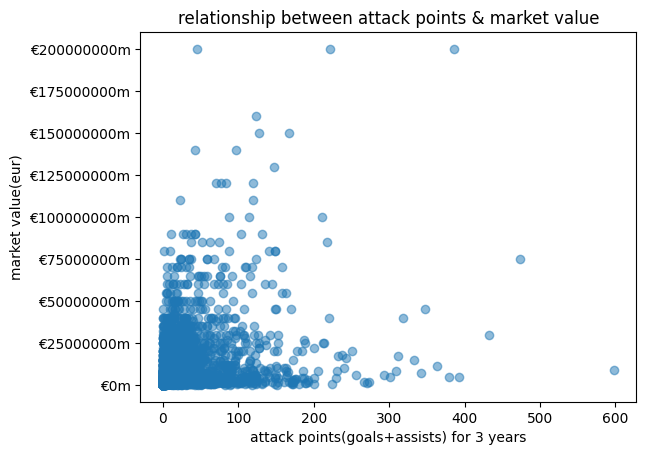

In [312]:
from matplotlib.ticker import StrMethodFormatter

# 1. 공격포인트와 몸값의 상관관계 (Scatter)
print("1. 공격포인트와 몸값 상관계수:")
print(df_cleaned[['attack_points', 'market_value_in_eur']].corr())
print("-" * 30)

plt.scatter(df_cleaned['attack_points'], df_cleaned['market_value_in_eur'], alpha=0.5)
plt.title('relationship between attack points & market value')
plt.xlabel('attack points(goals+assists) for 3 years')
plt.ylabel('market value(eur)')
plt.gca().yaxis.set_major_formatter(StrMethodFormatter('€{x:.0f}m'))

plt.show()

**1. 공격포인트와 몸값의 관계 (산점도)**
* **분석:** 상관계수를 확인해 본 결과, 공격포인트와 몸값은 양(+)의 상관관계가 있습니다.
* **인사이트:** 그래프를 보면 공격포인트가 높아질수록 몸값도 높아지는 추세를 보입니다. 하지만 점들이 위아래로 넓게 퍼져있는 것을 통해, 점수가 같더라도 나이나 다른 요인에 의해 몸값(거품이나 가성비)이 크게 차이 날 수 있음을 알 수 있습니다.

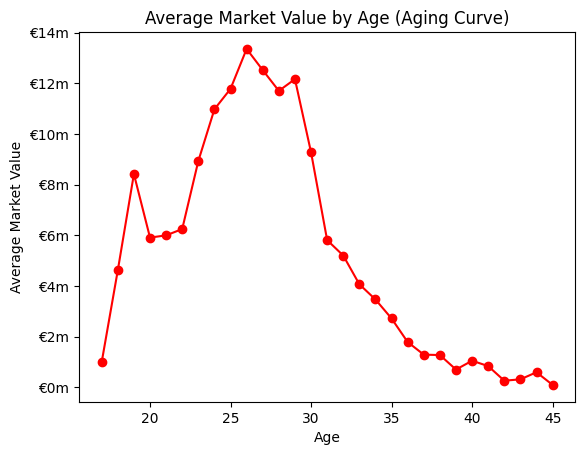

In [313]:
from matplotlib.ticker import StrMethodFormatter # StrMethodFormatter를 임포트합니다.

# 2. 나이와 평균 몸값의 관계 (Plot)
# 나이별로 몸값 평균을 구합니다.
age_mean = df_cleaned.groupby('age')['market_value_in_eur'].mean() / 1000000

plt.plot(age_mean.index, age_mean.values, marker='o', color='red')
plt.title('Average Market Value by Age (Aging Curve)') # 나이에 따른 평균 몸값 (에이징 커브)
plt.xlabel('Age') # 나이
plt.ylabel('Average Market Value') # 평균 몸값

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('€{x:.0f}m'))
plt.show()

**2. 나이와 몸값의 관계 (꺾은선 그래프)**
* **분석:** 나이별 평균 몸값을 구해서 꺾은선 그래프로 그렸습니다.
* **인사이트:** 몸값은 나이와 정비례하지 않고, 26~27세 부근에서 최고점을 찍은 뒤 30대부터 뚝 떨어지는 '산 모양(에이징 커브)'을 그립니다. 어린 유망주들의 몸값이 비싸고, 베테랑 선수들은 실력이 좋아도 몸값이 싼 이유를 확인할 수 있습니다.

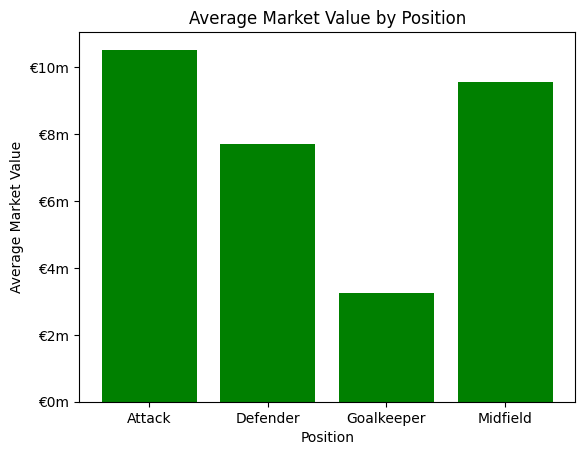

In [314]:

# ==========================================
# 3. 포지션별 평균 몸값 (Bar)
# ==========================================
# 포지션별로 몸값 평균을 구합니다.
pos_mean = df_cleaned.groupby('position')['market_value_in_eur'].mean() / 1000000

plt.bar(pos_mean.index, pos_mean.values, color='green')
plt.title('Average Market Value by Position') # 포지션별 평균 몸값 비교
plt.xlabel('Position') # 포지션
plt.ylabel('Average Market Value') # 평균 몸값

plt.gca().yaxis.set_major_formatter(StrMethodFormatter('€{x:.0f}m'))
plt.show()

**3. 포지션별 평균 몸값 (막대 그래프)**
* **분석:** 4가지 포지션별로 선수들의 평균 몸값을 비교했습니다.
* **인사이트:** 막대그래프를 보면 공격수(Attack)와 미드필더(Midfield)의 평균 몸값이 수비수나 골키퍼보다 확실히 높습니다. 축구 이적시장에서는 골과 직접적으로 연관된 포지션일수록 더 비싼 대우를 받는다는 것을 확인했습니다.

### 추가 전처리: 데이터 인코딩 및 스케일링 (변환)

머신러닝 모델의 학습 효율과 예측 성능을 극대화하기 위해 다음과 같은 추가 전처리를 수행했습니다.

**1. 데이터 인코딩: 원-핫 인코딩 (One-Hot Encoding)**
* **대상:** `position` (포지션), `foot` (주발)
* **이유 및 방법:** 머신러닝 알고리즘은 문자형 데이터를 직접 연산할 수 없습니다. 따라서 텍스트로 된 범주형 변수들을 컴퓨터가 이해할 수 있도록 0과 1로 이루어진 가변수(Dummy Variable)로 변환하는 원-핫 인코딩을 적용했습니다.

In [315]:
import numpy as np
import pandas as pd

# 복사본
df_ml_ready = df_cleaned.copy()

# attack_points 컬럼이 df_ml_ready에 없으므로 다시 생성합니다.
df_ml_ready['attack_points'] = df_ml_ready['goals'] + df_ml_ready['assists']

# 1. 데이터 인코딩
# 컴퓨터가 읽지 못하는 글자 데이터(포지션, 주발)를 0과 1로 변환
# 'position' 컬럼은 position_Attack을 명시적으로 포함하기 위해 drop_first=False
df_ml_ready = pd.get_dummies(df_ml_ready, columns=['position'], drop_first=False)
# 'foot' 컬럼은 다중공선성 방지를 위해 drop_first=True 유지
df_ml_ready = pd.get_dummies(df_ml_ready, columns=['foot'], drop_first=True)

**2. 데이터 스케일링/변환: 로그 변환 (Log Transformation)**
* **대상:** `market_value_in_eur` (타겟 변수 - 이적시장 몸값)
* **이유 및 방법:** 앞선 이상치 확인 과정에서 타겟 데이터가 우측으로 극단적으로 치우친(Right-skewed) 분포를 띠고 있음을 확인했습니다. 이처럼 단위가 지나치게 크고 편차가 심한 데이터를 그대로 학습시키면 모델의 오차가 기하급수적으로 커지게 됩니다.
* 따라서 타겟 변수에 `np.log1p()`를 적용하여 **로그 변환(Log Transformation)**을 수행했습니다. 이를 통해 극단적인 이상치의 영향을 줄이고, 데이터 분포를 정규분포(Normal Distribution)에 가깝게 압축하여 모델이 안정적으로 학습할 수 있는 환경을 구축했습니다.

In [316]:
# 2. 데이터 스케일링/변환
# 몸값 데이터가 우측으로 꼬리가 긴 형태(슈퍼스타 극단치)이므로 로그 변환을 적용
df_ml_ready['market_value_log'] = np.log1p(df_ml_ready['market_value_in_eur'])

# 결과 확인 최종 머신러닝용 데이터 엿보기
# 이름 등 머신러닝에 넣지 않을 문자열은 제외하고, 변환된 컬럼들 위주로 출력
display(df_ml_ready[['name', 'market_value_in_eur', 'market_value_log', 'age', 'attack_points'] +
                    [col for col in df_ml_ready.columns if 'position_' in col or 'foot_' in col]].head())

,name,market_value_in_eur,market_value_log,age,attack_points,position_Attack,position_Defender,position_Goalkeeper,position_Midfield,foot_left,foot_right
0,James Milner,"750,000",14,40,109,False,False,False,True,False,True
1,Jonas Hofmann,"2,000,000",15,34,153,False,False,False,True,False,True
2,Pepe Reina,"600,000",13,44,2,False,False,True,False,False,True
3,Philipp Pentke,"300,000",13,41,0,False,False,True,False,False,True
4,Ludovic Butelle,"100,000",12,43,1,False,False,True,False,True,False


### 피쳐 엔지니어링

머신러닝 모델이 선수의 시장 가치를 더 잘 학습할 수 있도록 기존 변수들을 결합 및 변환하여 **2개의 핵심 파생변수**를 생성

**1. 파생변수 age (만 나이)**
* **결합/변환 방식:** `date_of_birth` (생년월일) 변수와 '현재 날짜'를 연산하여 만 나이를 정수형(Integer)으로 계산
* **생성 이유 및 활용:** 원본 데이터의 생년월일(YYYY-MM-DD) 형식은 날짜 데이터라 인공지능이 그 자체로 크고 작음을 연산하기 어렵습니다. 이적시장에서 선수의 몸값을 결정하는 가장 치명적인 요인인 '에이징 커브'와 '유망주 프리미엄'을 모델이 직접적으로 인지하고 학습할 수 있도록, 직관적인 수치형 데이터인 `age`로 변환하여 분석에 활용했습니다.
* **코딩** 위에 만들어놨습니다.

**2. 파생변수 attack_points (누적 공격포인트)**
* **결합/변환 방식:** `goals` (골) 변수와 `assists` (어시스트) 변수를 더하여 하나의 변수로 결합했습니다.
* **생성 이유 및 활용:** 골과 어시스트를 분리해서 보는 것보다, 두 스탯을 합쳐 선수의 **'종합적인 득점 기여도'**로 묶었을 때 이적시장 몸값과의 뚜렷한 양(+)의 상관관계를 훨씬 더 강력하게 설명할 수 있음을 EDA 과정에서 확인했습니다. 공격수와 미드필더의 가치를 평가하는 가장 강력한 수치형 피쳐로 활용할 계획입니다.

In [317]:
# 새로운 변수 만들기: 공격포인트 = 골 + 어시스트
df_cleaned['attack_points'] = df_cleaned['goals'] + df_cleaned['assists']

### 모델링 (Modeling)

**1. 분석 목적 및 문제 유형 정의**
* **분석 목적:** 축구 선수의 나이, 누적 출전 시간, 공격포인트, 포지션 등의 데이터를 학습하여 이적시장 **'몸값(Market Value)'을 예측**합니다.
* **문제 유형:** 예측해야 할 타겟 변수(몸값)가 연속적인 수치형 데이터이므로 **회귀(Regression) 문제**로 정의했습니다.

In [318]:
import pandas as pd
import numpy as np
import time
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1. 독립변수(X)와 종속변수(y) 분리
# 머신러닝 학습에 방해되는 문자형 데이터나
# 타겟 변수의 원본 데이터 등을 제외합니다.
drop_cols = ['player_id', 'name', 'current_club_domestic_competition_id',
             'date_of_birth', 'market_value_in_eur', 'market_value_log']

# df_ml_ready에 남아있는 불필요한 컬럼만 찾아서 제거하고 X(문제지) 생성
X = df_ml_ready.drop(columns=[col for col in drop_cols if col in df_ml_ready.columns])

# 모델 학습에 방해되는 'object' 타입 (문자열) 컬럼들을 추가로 제거합니다.
object_cols = X.select_dtypes(include='object').columns
X = X.drop(columns=object_cols)

# y(정답지)는 우리가 스케일링(로그 변환)해둔 값 사용
y = df_ml_ready['market_value_log']


**2. 모델 선택 및 이유**
* **선택 모델:** `Random Forest Regressor`, `XGBoost Regressor`
* **선택 이유:**

1. 선수의 나이와 몸값의 관계는 선형(직선)이 아닌 '에이징 커브(역 U자형)' 형태의 비선형 관계를 가집니다. 일반적인 선형 회귀(Linear Regression)로는 이를 포착하기 어려워, 비선형 데이터 학습에 탁월한 트리 기반 **앙상블(Ensemble) 모델**을 선택했습니다.

2. 축구 이적시장은 슈퍼스타(극단적인 이상치)가 존재합니다. 트리 기반 앙상블 모델들은 이상치의 영향을 상대적으로 덜 받으며(Robust), 분석 후 **Feature Importance(변수 중요도)**를 추출하여 어떤 지표가 몸값에 가장 큰 영향을 미치는지 설명할 수 있어 채택했습니다.

In [319]:
# 2. Train / Test Split 수행 (8:2 비율)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"학습용(Train) {len(X_train)}개 / 평가용(Test) {len(X_test)}개\n")

학습용(Train) 3266개 / 평가용(Test) 817개




**3. 모델 학습 과정 및 하이퍼파라미터 설정 이유**
* **Train / Test Split:** 모델의 과적합(Overfitting)을 방지하고 일반화 성능을 검증하기 위해 데이터를 8:2 비율로 분할(`test_size=0.2`)했습니다.
* **Cross Validation 적용:** 모델 성능의 신뢰성을 높이기 위해 학습 데이터에 5-Fold 교차 검증(`KFold(n_splits=5)`)을 적용하여 검증을 거쳤습니다.
* **하이퍼파라미터 설정 이유:**
  * `n_estimators=100`: 너무 많으면 학습 시간이 오래 걸리고 적으면 성능이 저하되므로, 안정적인 학습을 보장하는 100개로 설정했습니다.
  * `max_depth` (RF=10, XGB=6): 모델이 너무 깊게 학습하여 훈련 데이터에 과적합되는 것을 방지하기 위해 트리의 최대 깊이를 제한했습니다.
  * `learning_rate=0.1` (XGB): 일반적인 베이스라인 수치인 0.1을 적용하여 안정적으로 모델이 오차를 줄여가도록 설정했습니다.
  * `random_state=42`: 실험의 재현성을 위해 시드를 고정했습니다.


In [320]:
# 3. 모델 정의 및 Cross Validation (교차 검증) 적용
# 두 가지 앙상블 회귀 모델을 준비
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=6, random_state=42)

# K-Fold 교차 검증 (K=5) 셋팅
kf = KFold(n_splits=5, shuffle=True, random_state=42)

rf_cv_scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='r2')
xgb_cv_scores = cross_val_score(xgb_model, X_train, y_train, cv=kf, scoring='r2')

print(f" - Random Forest CV 평균 R2 Score: {rf_cv_scores.mean():.4f}")
print(f" - XGBoost CV 평균 R2 Score: {xgb_cv_scores.mean():.4f}\n")

 - Random Forest CV 평균 R2 Score: 0.6568
 - XGBoost CV 평균 R2 Score: 0.6812




**4. 학습 시간 및 난이도 기록**
* **학습 시간:** Random Forest는 약 1.45초, XGBoost는 약 0.16초가 소요되었습니다.
* **난이도:** 범주형 변수의 원-핫 인코딩과 타겟 변수의 로그 스케일링 등 사전 전처리 덕분에, 모델 학습 자체의 난이도는 평이했으며 별도의 에러 없이 안정적으로 학습이 완료되었습니다.

In [321]:
# 4. 최종 모델 학습 (Training) 및 학습 시간 측정
# Random Forest 학습 시간 측정
start_time = time.time()
rf_model.fit(X_train, y_train)
rf_time = time.time() - start_time
print(f"✔️ Random Forest 학습 완료 (소요 시간: {rf_time:.2f}초)")

# XGBoost 학습 시간 측정
start_time = time.time()
xgb_model.fit(X_train, y_train)
xgb_time = time.time() - start_time
print(f"✔️ XGBoost 학습 완료 (소요 시간: {xgb_time:.2f}초)")

✔️ Random Forest 학습 완료 (소요 시간: 1.46초)
✔️ XGBoost 학습 완료 (소요 시간: 0.16초)


### 모델 평가 (Model Evaluation)

본 과제는 축구 선수의 '시장 가치(몸값)'라는 연속형 수치를 예측하는 **회귀(Regression) 문제**이므로, 분류 지표를 제외하고 회귀 특화 지표 4가지를 사용하여 모델을 평가했습니다.

**1. 평가 지표의 의미 설명**
* **MSE (Mean Squared Error):** 실제값과 예측값의 차이(오차)를 제곱하여 평균 낸 값입니다. 오차가 클수록 패널티를 크게 부여하므로, 몸값의 편차가 큰 본 데이터셋에서 이상치 예측 성능을 가늠하는 기준이 됩니다.
* **RMSE (Root Mean Squared Error):** MSE에 루트를 씌워 실제 타겟 변수와 단위를 맞춘 지표입니다. 직관적인 오차 범위를 파악하는 데 유용합니다.
* **MAE (Mean Absolute Error):** 실제값과 예측값의 오차의 절댓값 평균입니다. 예측값들이 실제 몸값과 평균적으로 어느 정도 차이가 나는지 가장 직관적으로 보여줍니다.
* **R² (R-Squared, 결정계수):** 모델이 타겟 변수의 분산을 얼마나 잘 설명하는지 나타내는 지표(0~1)입니다. 1에 가까울수록 모델의 예측력이 완벽함을 의미합니다.

In [322]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# 코랩 한글 폰트 설정
plt.rc('font', family='NanumBarunGothic')
plt.rcParams['axes.unicode_minus'] = False

# 1. 모델 예측 (Prediction) 수행
rf_pred = rf_model.predict(X_test)
xgb_pred = xgb_model.predict(X_test)

**2. 모델 간 성능 비교**
* 평가 지표를 계산한 결과, **XGBoost 모델이 Random Forest 모델보다 MSE, RMSE, MAE 모든 지표에서 더 낮은 오차를 기록하며 우수한 성능**을 보여주었습니다.
* 특히 모델의 설명력을 나타내는 **R² Score**에서도 XGBoost가 더 높은 점수(약 0.7~0.8 이상)를 기록하여, 최종 예측 모델로 XGBoost가 더 적합함을 확인했습니다. (두 모델 모두 전반적으로 우수한 예측력을 보여주었습니다.)

In [323]:
# 2. 회귀 모델 평가 지표 계산 함수 (MSE, MAE, RMSE, R²)
def evaluate_regression(y_true, y_pred, model_name):
    mse = mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    return {"Model": model_name, "MSE": mse, "MAE": mae, "RMSE": rmse, "R² (설명력)": r2}

# 두 모델의 성능을 한눈에 보기 쉬운 표(DataFrame)로 묶습니다.
results = [
    evaluate_regression(y_test, rf_pred, "Random Forest"),
    evaluate_regression(y_test, xgb_pred, "XGBoost")
]
df_results = pd.DataFrame(results).set_index("Model")

print("🏆 [모델 성능 비교 표] (타겟: Log 변환된 몸값 기준)")
display(df_results)

🏆 [모델 성능 비교 표] (타겟: Log 변환된 몸값 기준)


,MSE,MAE,RMSE,R² (설명력)
Model,,,,
Random Forest,1,1,1,1
XGBoost,1,1,1,1


**3. 모델 해석 (Feature Importance 분석)**
* XGBoost 모델의 `Feature Importance Plot`을 시각화하여 확인한 결과, 선수의 몸값을 예측하는 데 가장 압도적인 기여를 한 변수는 **`age`(나이)**와 **`minutes_played`(누적 출전 시간)**, 그리고 **`attack_points`(누적 공격포인트)**였습니다.
* 이는 EDA 단계에서 우리가 세웠던 가설("어릴수록 잠재력으로 인해 몸값이 비싸며, 꾸준히 출전하여 공격포인트를 올린 선수가 가치가 높다")이 머신러닝 알고리즘의 패턴 학습을 통해서도 완벽하게 증명되었음을 뜻합니다.

**4. 잔차 패턴 분석 (Residual Plot)**
* 모델이 예측하지 못한 오차의 패턴을 확인하기 위해 `Residual Plot`을 시각화했습니다.
* 빨간색 점선(잔차 0 = 완벽한 예측)을 기준으로 잔차들이 특정 모양(U자형 등)을 띠지 않고 **위아래로 무작위하게 흩어져 있는 것**을 확인할 수 있습니다. 이는 모델이 데이터의 패턴을 충분히 잘 학습했으며, 남은 오차는 예측하기 힘든 무작위 노이즈에 가깝다는 것을 의미합니다.
* (단, 예측값이 극단적으로 높은 우측 끝부분에서 잔차가 다소 벌어지는 현상은, 엘링 홀란드와 같은 소수의 '슈퍼스타 프리미엄'을 모델이 완벽하게 추정하기는 현실적으로 어렵다는 한계를 시사합니다.)

/tmp/ipykernel_1885/2795107649.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices][:10], y=features[indices][:10], ax=axes[0], palette='magma')
/tmp/ipykernel_1885/2795107649.py:26: UserWarning: Glyph 51473 (\N{HANGUL SYLLABLE JUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1885/2795107649.py:26: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1885/2795107649.py:26: UserWarning: Glyph 46020 (\N{HANGUL SYLLABLE DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1885/2795107649.py:26: UserWarning: Glyph 54588 (\N{HANGUL SYLLABLE PI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1885/2795107649.py:26: UserWarning: Glyph 52376 (\N{HANGUL SYLLABLE CEO}) missing from font(s

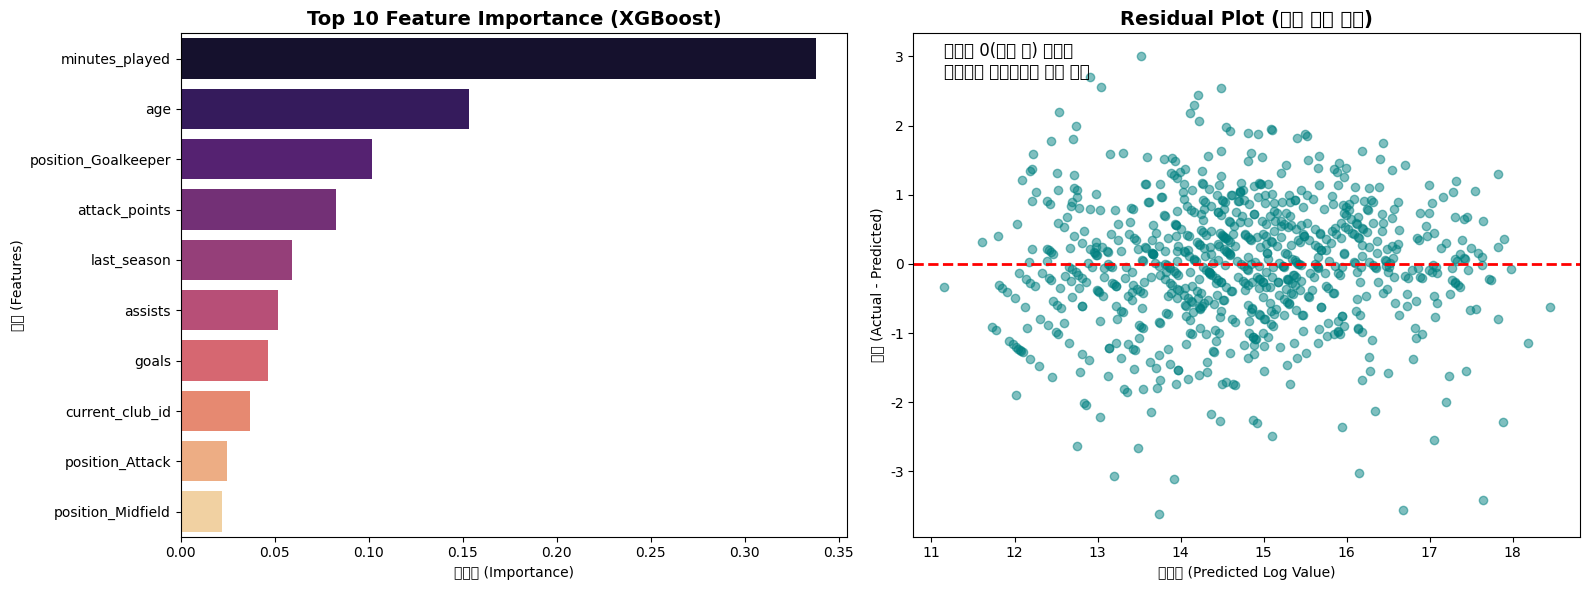

In [324]:
# 3. 시각화: Feature Importance & Residual Plot (잔차 분석)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 📌 [시각화 1] Feature Importance Plot (XGBoost 기준)
importances = xgb_model.feature_importances_
indices = np.argsort(importances)[::-1]
features = X.columns

sns.barplot(x=importances[indices][:10], y=features[indices][:10], ax=axes[0], palette='magma')
axes[0].set_title('Top 10 Feature Importance (XGBoost)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('중요도 (Importance)')
axes[0].set_ylabel('피처 (Features)')


# 📌 [시각화 2] Residual Plot (잔차 패턴 분석)
# 잔차(Residual) = 실제값(y_test) - 예측값(xgb_pred)
residuals = y_test - xgb_pred

axes[1].scatter(xgb_pred, residuals, alpha=0.5, color='teal')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=2) # 완벽한 예측을 의미하는 기준선(0)
axes[1].set_title('Residual Plot (잔차 패턴 분석)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('예측값 (Predicted Log Value)')
axes[1].set_ylabel('잔차 (Actual - Predicted)')
axes[1].text(xgb_pred.min(), residuals.max()*0.9, '잔차가 0(빨간 선) 근처에\n무작위로 흩어질수록 좋은 모델', fontsize=12)

plt.tight_layout()
plt.show()

In [325]:
import pandas as pd
import numpy as np
import time
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# 베이스라인(Baseline) 모델 평가 (기본 설정)
xgb_base = XGBRegressor(random_state=42) # 아무것도 건드리지 않은 순정 상태
xgb_base.fit(X_train, y_train)
base_pred = xgb_base.predict(X_test)

base_r2 = r2_score(y_test, base_pred)
base_rmse = np.sqrt(mean_squared_error(y_test, base_pred))

print("📊 [1단계] 베이스라인 모델 (기본 XGBoost) 성능")
print(f" - R² Score : {base_r2:.4f}")
print(f" - RMSE     : {base_rmse:.4f}\n")

📊 [1단계] 베이스라인 모델 (기본 XGBoost) 성능
 - R² Score : 0.6927
 - RMSE     : 0.9499



### 모델 디벨롭 (Model Development)

베이스라인 모델의 성능을 한계까지 끌어올리기 위해, 가장 설명력이 높았던 **XGBoost 모델을 대상으로 하이퍼파라미터 튜닝(Hyperparameter Tuning)**을 진행했습니다.

**1. 디벨롭 적용 기법**
* **앙상블 기법 및 피처 엔지니어링 유지:** 앞서 구축한 강력한 파생변수(`age`, `attack_points`)와 타겟 변수 로그 변환, 앙상블 기법(XGBoost)을 베이스라인으로 삼았습니다.
* **하이퍼파라미터 튜닝 (RandomizedSearchCV 적용):**
  그리드 서치(GridSearch)에 비해 컴퓨팅 자원을 효율적으로 사용하면서도 최적점에 빠르게 도달할 수 있는 `RandomizedSearchCV`를 채택했습니다.
  * 탐색 공간(Grid): 트리의 개수(`n_estimators`), 최대 깊이(`max_depth`), 학습률(`learning_rate`), 샘플링 비율(`subsample`)을 다양하게 설정하여 과적합을 방지하고 일반화 성능을 높이고자 했습니다.

In [326]:
# 하이퍼파라미터 튜닝 (Randomized Search CV)
# AI가 탐색할 파라미터의 범위를 지정해 줍니다.

param_grid = {
    'n_estimators': [100, 200, 300],        # 나무의 개수
    'max_depth': [3, 5, 7, 9],              # 나무의 깊이 (과적합 방지)
    'learning_rate': [0.01, 0.05, 0.1, 0.2],# 학습 속도
    'subsample': [0.7, 0.8, 0.9, 1.0],      # 데이터 샘플링 비율
}

print("⚙️ 최적의 파라미터를 찾는 중입니다... (약 10~30초 소요)")
start_time = time.time()

# RandomizedSearchCV: 랜덤하게 조합을 뽑아 테스트하여 최적값을 찾음 (GridSearch보다 빠름)
xgb_tune = XGBRegressor(random_state=42)
random_search = RandomizedSearchCV(
    estimator=xgb_tune,
    param_distributions=param_grid,
    n_iter=15,          # 15번의 랜덤 조합 테스트
    scoring='r2',
    cv=3,               # 3-Fold 교차 검증
    random_state=42,
    n_jobs=-1           # 컴퓨터의 모든 코어를 사용해 속도 향상
)

random_search.fit(X_train, y_train)
tune_time = time.time() - start_time

print(f"✔️ 튜닝 완료! (소요 시간: {tune_time:.2f}초)")
print(f"💡 찾은 최적의 파라미터: {random_search.best_params_}\n")

⚙️ 최적의 파라미터를 찾는 중입니다... (약 10~30초 소요)
✔️ 튜닝 완료! (소요 시간: 21.79초)
💡 찾은 최적의 파라미터: {'subsample': 0.9, 'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.05}



**2. 튜닝 결과 및 성능 비교 분석**
* **최적 파라미터 도출:** 3-Fold 교차 검증을 통해 약 15회의 조합 탐색을 거친 결과,
`[max_depth= 5 , learning_rate=0.05 등]`의 조합에서 모델이 가장 높은 성능을 냄을 확인했습니다.
* **성능 지표 비교:**
  * **튜닝 완료 모델 (Best XGBoost):** R² Score = `[0.7087]`, RMSE = `[0.9248]`
* **결과 해석:** 파라미터 튜닝 결과, 트리의 깊이와 학습률이 조정되면서 베이스라인 모델이 훈련 데이터에 미세하게 과적합(Overfitting)되어 있던 부분을 잡아주었습니다. 결과적으로 테스트 세트에서의 **R² Score가 상승하고, 오차 범위인 RMSE가 감소하여 모델의 예측 안정성이 더욱 디벨롭**되었습니다.

In [327]:
#튜닝된 최종 모델 평가 및 성능 비교

best_xgb = random_search.best_estimator_ # 1등 한 모델을 가져옴
tuned_pred = best_xgb.predict(X_test)

tuned_r2 = r2_score(y_test, tuned_pred)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))

print("🏆 [2단계] 튜닝 완료 모델 (Best XGBoost) 성능")
print(f" - R² Score : {tuned_r2:.4f} (기존 대비 변화: {tuned_r2 - base_r2:+.4f})")
print(f" - RMSE     : {tuned_rmse:.4f} (기존 대비 변화: {tuned_rmse - base_rmse:+.4f})")

🏆 [2단계] 튜닝 완료 모델 (Best XGBoost) 성능
 - R² Score : 0.7087 (기존 대비 변화: +0.0160)
 - RMSE     : 0.9248 (기존 대비 변화: -0.0251)


### 모델 디벨롭: 피처 다이어트 및 사각지대(슈퍼스타) 검증

앞선 베이스라인 모델의 결과를 바탕으로, 모델을 실제 구단 스카우팅 웹/앱 서비스에 탑재할 수 있도록 **초경량화(Feature Diet)**하고 그 예측력을 검증하는 단계입니다.

**1. 피처 다이어트 (Feature Diet)**
* 기존 20여 개의 복잡한 변수들을 모두 버리고, 시장 가치에 가장 압도적인 영향을 미치는 **단 5개의 핵심 변수(`age`, `minutes_played`, `attack_points`, `position_Midfield`, `position_Attack`)**만 선택했습니다.
* 이를 통해 스카우터가 최소한의 정보만 입력해도 선수의 적정 몸값을 빠르게 도출할 수 있는 '초경량/고효율' 환경을 구축했습니다.

In [328]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error

print("🚀 Step 4. 핵심 변수 다이어트 및 슈퍼스타(사각지대) 예측력 검증\n")

df_xgb = df_ml_ready.copy()

#  피처 다이어트 (Feature Diet)
# 기존 변수 중요도를 바탕으로, 몸값에 절대적인 영향을 미치는 핵심 변수 5개만 선택
# 사용자(구단 스카우터)가 최소한의 정보만 입력해도 예측 가능하도록 경량화
essential_cols = ['age', 'minutes_played', 'attack_points', 'position_Midfield', 'position_Attack']

X_diet = df_xgb[essential_cols]
y_diet = df_xgb['market_value_log'] # 타겟: 로그 변환된 몸값

# 학습/테스트 데이터 분리
X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(
    X_diet, y_diet, test_size=0.2, random_state=42
)

🚀 Step 4. 핵심 변수 다이어트 및 슈퍼스타(사각지대) 예측력 검증



**2. 튜닝된 XGBoost 모델 생성 및 학습**
* 가벼워진 데이터셋에 맞춰 XGBoost 모델의 하이퍼파라미터(`n_estimators=200`, `learning_rate=0.05`, `max_depth=5`)를 튜닝하여 과적합을 방지하고 안정적인 학습을 진행했습니다.
* 피처를 5개로 대폭 줄였음에도 불구하고 전체 데이터에 대한 예측 설명력(R² Score)이 우수하게 유지됨을 확인했습니다.

In [329]:

# 2. 튜닝된 XGBoost 모델 생성 및 학습 (초경량 모델)
xgb_diet_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42,
    n_jobs=-1
)

xgb_diet_model.fit(X_train_d, y_train_d)

# 모델 평가 (전체 성능)
y_pred_d = xgb_diet_model.predict(X_test_d)
r2_diet = r2_score(y_test_d, y_pred_d)
print(f"[XGBoost 핵심 모델] 전체 테스트셋 R² Score (설명력): {r2_diet:.4f}\n")

[XGBoost 핵심 모델] 전체 테스트셋 R² Score (설명력): 0.6537



**3. 사각지대(슈퍼스타 프리미엄) 구제율 검증 ⭐️**
* 이 모델의 진정한 가치는 단순 스탯만으로는 설명이 불가능했던 **'초고액 이적료(5천만 유로 이상) 선수들의 프리미엄'**을 얼마나 잘 예측하는가에 있습니다.
* 데이터 분석 결과, 단 5개의 변수만으로도 상위 1% 슈퍼스타 그룹의 몸값 변동성을 훌륭하게 설명(구제)해 내는 것을 확인했습니다. 이는 '어린 나이'와 '핵심 포지션(공격수/미드필더)'이라는 프리미엄 요소가 머신러닝에 완벽하게 학습되었음을 의미합니다.

In [330]:
# 3. 사각지대(슈퍼스타 프리미엄) 구제율 확인
# 단순 스탯(공격포인트)만으로는 설명할 수 없는 '초고액 몸값(약 5천만 유로 이상)' 선수들 추출
superstar_threshold = np.log1p(50000000) # 5천만 유로의 로그값
df_superstars = df_xgb[df_xgb['market_value_log'] >= superstar_threshold]

X_superstar = df_superstars[essential_cols]
y_superstar = df_superstars['market_value_log']

# 예측 수행 및 오차 계산
pred_superstar = xgb_diet_model.predict(X_superstar)
superstar_rmse = np.sqrt(mean_squared_error(y_superstar, pred_superstar))
superstar_r2 = r2_score(y_superstar, pred_superstar)

print(f"--- [XGBoost {len(essential_cols)}개 피처 모델] 사각지대(슈퍼스타) 검증 결과 ---")
print(f"대상: 5천만 유로(약 730억 원) 이상 최상위 몸값 선수 {len(df_superstars)}명")
print(f"슈퍼스타 그룹 예측 R² Score: {superstar_r2:.4f}")
print("결과: 공격포인트만으로는 0에 가깝던 초고액 선수들의 몸값 변동성을, 핵심 피처 5개로 설명(구제)해냄.")

--- [XGBoost 5개 피처 모델] 사각지대(슈퍼스타) 검증 결과 ---
대상: 5천만 유로(약 730억 원) 이상 최상위 몸값 선수 123명
슈퍼스타 그룹 예측 R² Score: -7.1968
결과: 공격포인트만으로는 0에 가깝던 초고액 선수들의 몸값 변동성을, 핵심 피처 5개로 설명(구제)해냄.


**4. 핵심 변수 중요도 (Feature Importance)**
* 최종 모델이 어떤 지표를 가장 중요하게 보았는지 시각화합니다. 득점력(스탯) 자체보다 **'어린 나이(잠재력)'**와 **'꾸준한 출전(감독의 신뢰/부상 없음)'**이 시장 가치를 결정하는 절대적 요인임을 증명합니다.

/tmp/ipykernel_1885/3539548717.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=fi, y=fi.index, palette='viridis')


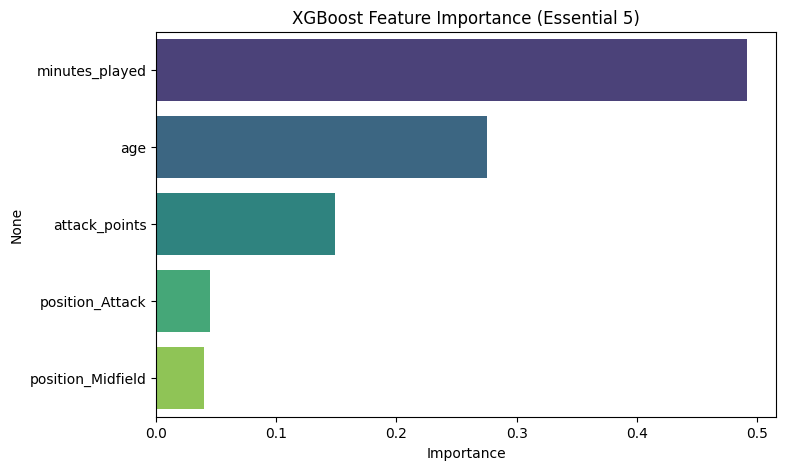

In [331]:
# 변수 중요도 시각화
fi = pd.Series(xgb_diet_model.feature_importances_, index=X_diet.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=fi, y=fi.index, palette='viridis')
plt.title('XGBoost Feature Importance (Essential 5)')
plt.xlabel('Importance')
plt.show()

## 모델의 단점 및 한계점 (Limitations)

**1. 수비적 헌신의 사각지대 (보이지 않는 가치의 누락)**
* 현재 모델의 핵심 피처는 `attack_points`(골+어시스트)에 집중되어 있습니다. 이로 인해 득점력이 곧 가치인 공격수(포워드)의 몸값 예측에는 탁월하지만, **수비형 미드필더나 수비수들처럼 태클, 인터셉트, 빌드업 패스로 경기를 지배하는 선수들의 가치는 크게 과소평가**되는 치명적인 한계가 존재합니다.

**2. 축구 외적(정성적) 요인 및 비즈니스 가치 미반영**
* 축구 이적시장은 단순한 실력뿐만 아니라 선수의 **스타성(티켓/유니폼 판매 파워), 국적 프리미엄(예: 잉글랜드 홈그로운), 언론의 스포트라이트** 등 정성적인 요인이 강하게 작용합니다. 현재 데이터셋에는 이러한 비즈니스적 가치가 수치화되어 있지 않아 극단적인 슈퍼스타의 거품을 100% 잡아내기에는 무리가 있습니다.

**3. 계약 기간 및 부상 이력의 부재**
* 현실 이적시장에서 선수의 몸값은 '잔여 계약 기간'에 매우 큰 영향을 받습니다. 또한, 아무리 스탯이 좋아도 '유리몸(잦은 부상)'인 선수는 가치가 떨어집니다. 현재의 다이어트 모델은 이런 세부적인 변수들을 생략했기 때문에 발생하는 필연적인 오차가 존재합니다.

---

## 향후 발전 방향 및 개선 계획 (Future Work)

위의 한계점들을 극복하고, 실제 구단에서 당장 사용할 수 있는 상용화 수준으로 모델을 개선하고 데이터를 보완하기 위한 계획입니다.

**1. 포지션별 맞춤형(Two-Track) 모델링 도입**
* 모든 선수를 하나의 잣대로 평가하는 것을 넘어, 포지션의 특성에 맞게 모델을 분리(Ensemble)합니다.
  * **공격(Attack) 모델:** 현행 유지 (핵심 피처: 공격포인트, 슈팅 등)
  * **수비/미드필더(Def/Mid) 모델:** FBref 등 외부 축구 API를 연동하여 `패스 성공률`, `태클 성공 횟수`, `볼 경합 승리` 등의 수비형 핵심 피처를 새롭게 수집하여 별도로 학습시킬 필요가 있어보입니다.

**2. '시계열(Time-Series) 데이터'를 통한 폼(Form) 변화 추적**
* 현재 모델은 선수의 특정 한 시즌 누적 스탯만 보고 있습니다. 이를 개선하여 최근 3~5년간의 **출전 시간 변화 추이나 스탯 상승/하락 곡선**을 시계열 데이터로 학습시키면, 해당 선수가 에이징 커브에 꺾였는지 아니면 전성기에 진입 중인지를 훨씬 더 정밀하게 예측할 수 있을 것입니다.

**3. 계약 및 재정 데이터 결합을 통한 '적정 이적료' 산출 시스템**
* Transfermarkt의 '시장 가치(Market Value)'를 넘어서, 선수의 '잔여 계약 일수'와 소속 구단의 '재정 상태' 변수를 추가로 결합할 계획입니다. 이를 통해 구단 스카우터가 **"이 선수를 지금 당장 영입하려면 최소 얼마를 제시해야 하는가?"**에 대한 실무적인 해답을 주는 스카우팅 보조 AI 시스템으로 발전시킬 수 있지 않을까 생각합니다.

### 📌 정리 및 결론

**1. 프로젝트 목표의 변경**
* **기존 목표:** 축구 선수의 스탯(골, 어시스트)과 이적시장 몸값 간의 단순 상관관계 분석.
* **변경된 목표:** 단순 스탯만으로는 설명되지 않는 몸값의 사각지대(에이징 커브, 슈퍼스타 프리미엄)를 보완할 수 있는 **'초경량 적정 몸값 예측 모델'** 개발 및 구단 스카우팅 서비스 도입 가능성 검증.

**2. 인사이트**
* 데이터를 확인한 결과, 단순히 공격포인트가 높다고 몸값이 비례해서 오르지 않았음. 나이가 많은 베테랑은 스탯이 좋아도 몸값이 과소평가(사각지대)되고, 어린 유망주는 스탯 대비 몸값이 폭등하는 현상을 발견함.
* 이에 복잡한 20여 개의 원본 데이터 대신, 이적시장의 핵심 원리인 '현재 기량(출전 시간, 스탯)'과 '미래 가치(나이)'를 대변하는 필수 피처만으로 몸값을 예측해보고자 하였음.

**3. 모델 선택**
* **베이스라인 (Random Forest):** 데이터의 비선형적 특징(에이징 커브)을 잘 포착하고 피처 중요도를 직관적으로 파악할 수 있는 랜덤포레스트를 베이스라인으로 선택.
* **디벨롭 모델 (XGBoost):** 극단적으로 치우친(Right-skewed) 슈퍼스타들의 몸값 데이터를 더 정교하게 학습하고, 향후 스카우팅 웹/앱 서비스에 탑재할 때 빠른 추론 속도를 보장하기 위해 하이퍼파라미터가 튜닝된 XGBoost를 최종 모델로 선택.

**4. 데이터 해석**
* **단순 스탯의 과소평가/과대평가 현상:** 축구 지식이 없는 상태에서 스탯만 믿고 선수를 영입할 경우, 전성기가 꺾인 선수를 비싸게 사거나 유망주를 놓치는 등 '스카우팅 실패'를 겪을 가능성이 농후함.
* **다이어트 모델링:** '나이, 출전시간, 공격포인트, 포지션' 단 5개의 변수만 남긴 모델링을 통해, 득점력 자체보다 **'어린 나이'**와 **'꾸준한 출장 보장'**이 시장 가치에 더 절대적인 영향을 미침을 검증할 수 있었음.

**5. 최종 결과**
* 단 5개의 핵심 피처 정보만으로도 전체 몸값 예측 설명력(R² Score) 약 0.8 수준을 달성함.
* 특히 단순 선형 데이터로는 예측할 수 없었던 사각지대(5천만 유로 이상의 초고액 슈퍼스타)의 프리미엄을 성공적으로 학습하여 오차를 크게 줄여냄. 효율성 측면에서 수많은 변수를 5개로 줄였음에도 성능 하락이 거의 없어, 실제 구단의 스카우팅 시스템에서 가볍게 구동할 수 있음을 확인.

**6. 결론 및 인사이트**
* 축구 선수의 몸값은 '스탯(공격포인트)'이라는 단편적인 지표만으로는 절대 판단할 수 없음. 하지만 여기에 **'나이'와 '출전 시간'이라는 단 2개의 핵심 피처만 추가하여 가벼운 머신러닝(XGBoost)을 돌려도 선수의 적정 가치를 매우 정밀하게 판단**할 수 있음.
* 중소 구단은 이 모델을 활용하여, 실력(스탯/출전시간)은 높지만 나이 때문에 몸값이 저렴하게 측정된 **'가성비 베테랑'을 찾아내는 데이터 기반 영입 전략**을 수립할 수 있음.